In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from sklearn import preprocessing as p

## Cleaning data

In [ ]:
#importing data from Modulair MOD-00068
winddata = pd.read_csv('MOD-00683.csv').set_index('timestamp')
winddata.head()

,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,bin4,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-29T16:55:02Z,576028598,2025-12-29T11:55:02Z,MOD-00683,96.3,8.8,42.941,17.835,6.328,1.280,0.876,...,NaN,NaN,16587,16588,16589,NaN,NaN,NaN,NaN,7.13
2025-12-29T16:54:02Z,576028597,2025-12-29T11:54:02Z,MOD-00683,96.0,8.8,41.879,16.737,5.744,1.112,0.770,...,NaN,NaN,16587,16588,16589,NaN,NaN,NaN,NaN,6.67
2025-12-29T16:53:02Z,576028596,2025-12-29T11:53:02Z,MOD-00683,95.6,8.8,42.907,16.337,6.045,1.202,0.752,...,NaN,NaN,16587,16588,16589,NaN,NaN,NaN,NaN,5.51
2025-12-29T16:35:06Z,576019139,2025-12-29T11:35:06Z,MOD-00683,94.9,8.6,36.847,14.615,5.084,1.031,0.690,...,NaN,NaN,16587,16588,16589,NaN,NaN,NaN,NaN,4.88
2025-12-29T16:34:06Z,576019142,2025-12-29T11:34:06Z,MOD-00683,94.7,8.5,35.261,13.451,5.089,0.894,0.498,...,NaN,NaN,16587,16588,16589,NaN,NaN,NaN,NaN,6.94


In [ ]:
#only columns of interest
COLS_TO_INCLUDE = ['timestamp_local','wd','ws']
winddata = winddata[COLS_TO_INCLUDE]

winddata.head()

,timestamp_local,wd,ws
timestamp,,,
2025-12-29T16:55:02Z,2025-12-29T11:55:02Z,207.0,6.86
2025-12-29T16:54:02Z,2025-12-29T11:54:02Z,226.2,6.30
2025-12-29T16:53:02Z,2025-12-29T11:53:02Z,230.0,5.28
2025-12-29T16:35:06Z,2025-12-29T11:35:06Z,215.4,4.70
2025-12-29T16:34:06Z,2025-12-29T11:34:06Z,224.0,6.84


In [ ]:
#removing the UTC time
winddata = winddata.reset_index(drop = True)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-29T11:55:02Z,207.0,6.86
1,2025-12-29T11:54:02Z,226.2,6.30
2,2025-12-29T11:53:02Z,230.0,5.28
3,2025-12-29T11:35:06Z,215.4,4.70
4,2025-12-29T11:34:06Z,224.0,6.84


In [ ]:
#converting to datetime
winddata['timestamp_local'] = pd.to_datetime(winddata['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-29 11:55:02,207.0,6.86
1,2025-12-29 11:54:02,226.2,6.30
2,2025-12-29 11:53:02,230.0,5.28
3,2025-12-29 11:35:06,215.4,4.70
4,2025-12-29 11:34:06,224.0,6.84


In [ ]:
#taking hourly average of df. round to floor of the hour
winddata = winddata.groupby(winddata['timestamp_local'].dt.floor('h')).agg(wd = ('wd','mean'),
                                                                           ws = ('ws','mean')).reset_index()

winddata = winddata.round(decimals = 2)
winddata = winddata.dropna()
winddata

,timestamp_local,wd,ws
0,2025-04-15 08:00:00,0.00,0.00
1,2025-04-15 11:00:00,314.50,4.20
2,2025-04-15 12:00:00,248.76,6.00
3,2025-04-15 13:00:00,228.36,8.62
4,2025-04-15 14:00:00,224.33,10.66
...,...,...,...
5986,2025-12-27 16:00:00,283.00,1.68
5987,2025-12-27 17:00:00,270.48,1.21
5988,2025-12-29 07:00:00,135.22,1.30
5989,2025-12-29 10:00:00,218.25,4.22


In [ ]:
ts = pd.read_csv('MOD-00683_timeseries_hourly_scaled.csv').reset_index()
ts.head()

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,0,2025-04-15 12:00:00,0.473146,0.581735,0.753736,0.041589,0.103624,0.025592,0.018170,0.018617,0.037037,0.041420
1,1,2025-04-15 13:00:00,0.431304,0.492153,0.728937,0.049737,0.063488,0.016635,0.012786,0.013298,0.029630,0.035503
2,2,2025-04-15 14:00:00,0.355810,0.171970,0.716266,0.050586,0.033933,0.011196,0.010094,0.013298,0.029630,0.035503
3,3,2025-04-15 15:00:00,0.328399,0.182868,0.718432,0.048379,0.021892,0.009277,0.008748,0.010638,0.029630,0.035503
4,4,2025-04-15 16:00:00,0.319780,0.307977,0.684644,0.034290,0.018122,0.007678,0.008075,0.010638,0.025926,0.029586


In [ ]:
results = pd.read_csv('4_factor_results.csv')
results.head()

,timestamp_local,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-04-15 12:00:00,0.076130,0.011327,0.072640,0.008059
1,2025-04-15 13:00:00,0.074788,0.002060,0.059946,0.005969
2,2025-04-15 14:00:00,0.074691,0.000000,0.012826,0.006523
3,2025-04-15 15:00:00,0.073792,0.000000,0.013462,0.005133
4,2025-04-15 16:00:00,0.069075,0.000000,0.031942,0.002815


## Merging dataframes

In [ ]:
data_1_2 = pd.merge(ts, results, on = 'timestamp_local', how = 'inner')
data_1_2

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4
0,0,2025-04-15 12:00:00,0.473146,0.581735,0.753736,0.041589,0.103624,0.025592,0.018170,0.018617,0.037037,0.041420,0.076130,0.011327,0.072640,0.008059
1,1,2025-04-15 13:00:00,0.431304,0.492153,0.728937,0.049737,0.063488,0.016635,0.012786,0.013298,0.029630,0.035503,0.074788,0.002060,0.059946,0.005969
2,2,2025-04-15 14:00:00,0.355810,0.171970,0.716266,0.050586,0.033933,0.011196,0.010094,0.013298,0.029630,0.035503,0.074691,0.000000,0.012826,0.006523
3,3,2025-04-15 15:00:00,0.328399,0.182868,0.718432,0.048379,0.021892,0.009277,0.008748,0.010638,0.029630,0.035503,0.073792,0.000000,0.013462,0.005133
4,4,2025-04-15 16:00:00,0.319780,0.307977,0.684644,0.034290,0.018122,0.007678,0.008075,0.010638,0.025926,0.029586,0.069075,0.000000,0.031942,0.002815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5816,5816,2025-12-27 13:00:00,0.436934,0.606146,0.338856,0.027669,0.058502,0.023672,0.018170,0.015957,0.025926,0.029586,0.036852,0.012209,0.088146,0.011322
5817,5817,2025-12-27 14:00:00,0.472978,0.598300,0.338965,0.029367,0.060448,0.021753,0.014132,0.013298,0.022222,0.023669,0.037874,0.014056,0.088127,0.008912
5818,5818,2025-12-27 15:00:00,0.491520,0.615301,0.326186,0.029706,0.059110,0.021433,0.015478,0.013298,0.022222,0.023669,0.037061,0.014574,0.091505,0.009460
5819,5819,2025-12-27 16:00:00,0.473137,0.640584,0.305501,0.032422,0.062150,0.021753,0.015478,0.013298,0.022222,0.017751,0.034260,0.015173,0.095149,0.008179


In [ ]:
data_1_2['timestamp_local'] = pd.to_datetime(data_1_2['timestamp_local'])

In [ ]:
data = pd.merge(data_1_2, winddata, on = 'timestamp_local', how = 'inner')
data

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4,wd,ws
0,0,2025-04-15 12:00:00,0.473146,0.581735,0.753736,0.041589,0.103624,0.025592,0.018170,0.018617,0.037037,0.041420,0.076130,0.011327,0.072640,0.008059,248.76,6.00
1,1,2025-04-15 13:00:00,0.431304,0.492153,0.728937,0.049737,0.063488,0.016635,0.012786,0.013298,0.029630,0.035503,0.074788,0.002060,0.059946,0.005969,228.36,8.62
2,2,2025-04-15 14:00:00,0.355810,0.171970,0.716266,0.050586,0.033933,0.011196,0.010094,0.013298,0.029630,0.035503,0.074691,0.000000,0.012826,0.006523,224.33,10.66
3,3,2025-04-15 15:00:00,0.328399,0.182868,0.718432,0.048379,0.021892,0.009277,0.008748,0.010638,0.029630,0.035503,0.073792,0.000000,0.013462,0.005133,230.66,11.74
4,4,2025-04-15 16:00:00,0.319780,0.307977,0.684644,0.034290,0.018122,0.007678,0.008075,0.010638,0.025926,0.029586,0.069075,0.000000,0.031942,0.002815,277.50,8.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5816,5816,2025-12-27 13:00:00,0.436934,0.606146,0.338856,0.027669,0.058502,0.023672,0.018170,0.015957,0.025926,0.029586,0.036852,0.012209,0.088146,0.011322,242.54,1.79
5817,5817,2025-12-27 14:00:00,0.472978,0.598300,0.338965,0.029367,0.060448,0.021753,0.014132,0.013298,0.022222,0.023669,0.037874,0.014056,0.088127,0.008912,291.63,1.77
5818,5818,2025-12-27 15:00:00,0.491520,0.615301,0.326186,0.029706,0.059110,0.021433,0.015478,0.013298,0.022222,0.023669,0.037061,0.014574,0.091505,0.009460,297.41,1.45
5819,5819,2025-12-27 16:00:00,0.473137,0.640584,0.305501,0.032422,0.062150,0.021753,0.015478,0.013298,0.022222,0.017751,0.034260,0.015173,0.095149,0.008179,283.00,1.68


## Plots

In [ ]:
wd_rad = np.radians(np.array(data['wd'])) #deg to rad
ws = np.array(data['ws']) #m/s
Factor1 = np.array(data['Factor 1'])
Factor2 = np.array(data['Factor 2'])
Factor3 = np.array(data['Factor 3'])
Factor4 = np.array(data['Factor 4'])

In [ ]:
WD, WS = np.meshgrid(np.linspace(0, 2*np.pi, 36), np.linspace(min(ws), max(ws), 16 ))
Z1 = interpolate.griddata((wd_rad, ws), Factor1, (WD, WS), method='linear')
Z2 = interpolate.griddata((wd_rad, ws), Factor2, (WD, WS), method='linear')
Z3 = interpolate.griddata((wd_rad, ws), Factor3, (WD, WS), method='linear')
Z4 = interpolate.griddata((wd_rad, ws), Factor4, (WD, WS), method='linear')

Z1 = np.nan_to_num(Z1, nan=1e-3)
Z2 = np.nan_to_num(Z2, nan=1e-3)
Z3 = np.nan_to_num(Z3, nan=1e-3)
Z4 = np.nan_to_num(Z4, nan=1e-3)

In [ ]:
maxima = [np.max(i) for i in [Z1,Z2,Z3,Z4]]
maxima

[np.float64(0.07091284244371561),
 np.float64(0.18461453478367626),
 np.float64(0.10622011237322736),
 np.float64(0.14382802041223633)]

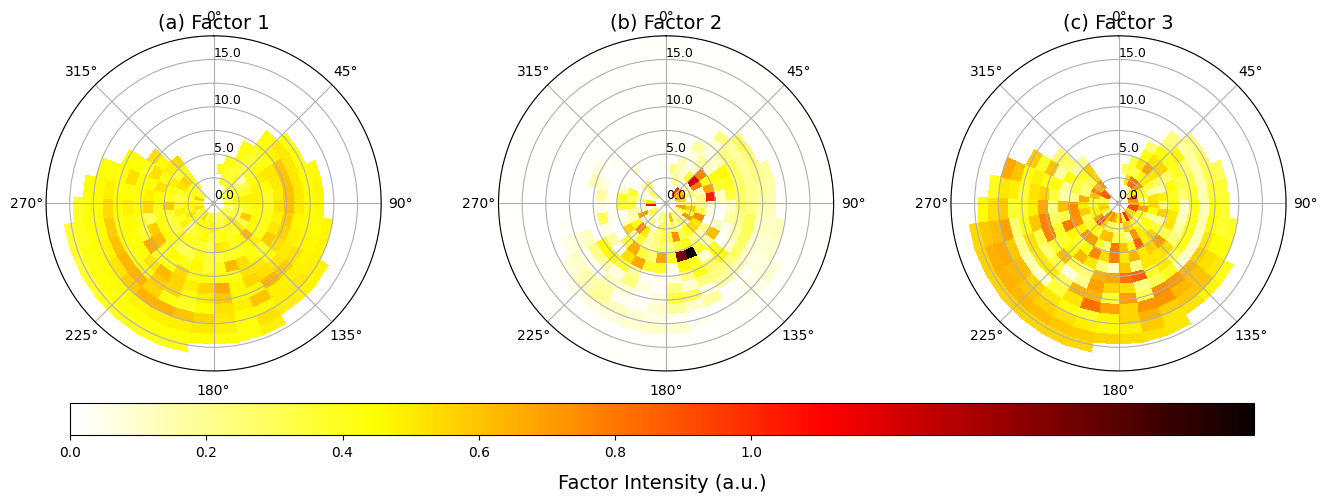

In [ ]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 16), subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace=0.35)
cmap = plt.get_cmap('hot_r')
cmap.set_under('none')

#change set-up to compass bearings
for i in range(3):
    ax[i].set_theta_zero_location('N')
    ax[i].set_theta_direction(-1)

#label
ax[0].set_title('(a) Factor 1',fontsize=14)
ax[1].set_title('(b) Factor 2',fontsize=14)
ax[2].set_title('(c) Factor 3',fontsize=14)

#plot
img1 = ax[0].pcolormesh(WD, WS, Z1, cmap=cmap, vmax = np.max(Z2))
img2 = ax[1].pcolormesh(WD, WS, Z2, cmap=cmap, vmax = np.max(Z2))
img3 = ax[2].pcolormesh(WD, WS, Z3, cmap=cmap, vmax = np.max(Z2))

#label radial ticks
for i in range(3):
    ax[i].tick_params(axis='y', which='major', labelsize=9)
    ax[i].set_rticks([0,2.5,5,7.5,10,12.5,15,17.5])
    ax[i].set_rlabel_position(0)
    ax[i].set_yticklabels(['0.0','','5.0','','10.0','','15.0',''])

#set colorbar
cbar_ax = fig.add_axes([0.14, 0.35, 0.74, 0.02])
cbar = fig.colorbar(img3, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks(list(np.linspace(0, np.max(Z3), 6)))
cbar.set_ticklabels([0.0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label('Factor Intensity (a.u.)', labelpad = 10, fontsize = 14)
cbar.ax.xaxis.set_label_position('bottom')

#fig.savefig('windrose_MOD-00683.png')